# AFMA Quant-AI Lab | Project 02: Density Forecasting

<p style="font-size: large; font-style: italic;">Chapter 03 — Part I: The Deep Hybrid Transition</p>

---

## The Story So Far

The previous two chapters established a hard empirical ceiling.

**Chapter 01** framed the problem: instead of predicting a single number (Value at Risk), we want to forecast the *entire probability distribution* of tomorrow's returns — one model that simultaneously answers "what is my alpha?" and "what is my tail risk?"

**Chapter 02** then exhausted the best tools classical finance has to offer:

| Model | Core Idea | Fatal Flaw |
|:---|:---|:---|
| Rolling Gaussian | μ + σ from a lookback window | Fat tails; underestimates crashes |
| Rolling Student-t | MLE-fitted ν, μ, σ each day | Still strictly backward-looking |
| GARCH(1,1) | Explicit volatility clustering | Reacts *after* the regime shift |
| **VIX-Scaled Student-t** | Injects options-market "fear" | Blind to idiosyncratic shocks |

The **VIX-Scaled Student-t** was our undisputed classical champion — combining structural fat tails with a forward-looking options signal. Yet even this model failed between **15 – 37 %** of 66-day independent market regimes across our three stress-test assets (`ARKK`, `USO`, `BTC-USD`).

The root cause is fundamental: every classical model is built on a **rigid, hand-crafted equation**. It cannot learn the complex, asset-specific, non-linear geometry that lives inside price paths. Bitcoin's weekend exchange collapses, USO's supply-shock spikes, ARKK's sentiment-driven drawdowns — none of these can be captured by a formula anchored to historical statistics and a US equity fear gauge.

---

## Chapter 03 Objective: The Deep Hybrid

> **Can a neural network learn to predict the parameters of a Student-t distribution better than the best classical models, while maintaining strict point-in-time integrity?**

The strategy is deliberately conservative: we do **not** discard the classical model. Instead, we treat its output as a **prior** and let a neural network learn the *residual correction*.

### Architecture: Physics-Informed Residual Network

The key insight from Project 01 (Deep VaR) carries forward here:

> *Anchoring a neural network to statistical theory creates a "Deep Hybrid" that is both robust and adaptive.*

We build two candidate architectures:

**`BasicStudentTNet`** — A simple feed-forward network with a shared hidden layer and three independent output heads, one per distribution parameter (μ, σ, ν). No prior knowledge is injected; the network must learn everything from scratch.

**`ResidualStudentTNet`** — A physics-informed residual network. The first three input features are the *rolling Student-t parameters* (μ_hist, σ_hist, ν_hist) computed from a lookback window. The network is trained to output **deltas** (Δμ, Δσ, Δν) on top of those priors, not absolute values. The residual connection forces the model to start from statistical theory and only deviate when the data justifies it.

```
Input: [μ_hist, σ_hist, ν_hist | VIX(t-1) | ret₁, ret₂, ..., ret₅]
         └── Historical priors ─┘   └─ Regime ─┘  └── Momentum ──┘

ResidualStudentTNet:
  ┌──────────────────────────────────────┐
  │  Shared hidden  →  Δμ, Δσ, Δν heads  │
  └──────────────────────────────────────┘
         +            +            +
      μ_hist       σ_hist       ν_hist
         │            │            │
        μ_pred   softplus(·) + ε  softplus(·) + 2.1
```

The `Softplus` activations guarantee σ > 0 and ν > 2 (finite-variance Student-t), making the physics constraints hard-coded into the architecture.

---

## Training Strategy: Strict Walk-Forward Backtest

To avoid any form of look-ahead bias, training follows a **strict point-in-time walk-forward** protocol:

1. **Initial burn-in:** The first `initial_train_size = 252 × 6` days (~6 years) are used as the first training set.
2. **Roll forward:** Every `step_size = 22` days (~1 trading month), the model is retrained on all data available up to that point.
3. **Warm-start:** Weights from the previous window initialise the next window, with a reduced learning rate (`lr = 0.001`, `50 epochs`) vs. the cold-start (`lr = 0.005`, `150 epochs`). This dramatically speeds up convergence.
4. **Best-weights checkpoint:** Within each training loop, the weights with the lowest training NLL are saved and restored before inference — preventing the model from returning a locally degraded solution.

The **Negative Log-Likelihood (NLL)** of the Student-t distribution is the sole training objective:

$$\mathcal{L}(\mu, \sigma, \nu) = -\frac{1}{N}\sum_{i=1}^{N} \log p_{\text{Student-t}}(r_i \mid \mu_i, \sigma_i, \nu_i)$$

No regularisation term beyond L2 weight decay (`weight_decay=1e-4`) and gradient clipping (`max_norm=1.0`).

---

## Evaluation

Out-of-sample predictions generate a **Monte Carlo ensemble** of 1 000 scenarios per day by drawing from the predicted Student-t(ν, μ, σ). These ensembles are then evaluated via the same three-lens framework used throughout the project:

| Metric | Question |
|:---|:---|
| **PIT** (Probability Integral Transform) | Is the model calibrated? (KS test) |
| **CRPS** (Continuous Ranked Probability Score) | How close is the whole distribution to reality? |
| **Log-Likelihood** | How much probability did we assign to what actually happened? |

Calibration is formally validated using the **Non-Overlapping 66-Day Independent Block KS Test** — the same protocol from Chapters 01 & 02 — which eliminates autocorrelation between windows and isolates genuine structural failures.



In [46]:
import numpy as np
import pandas as pd
from datetime import date

import torch

import matplotlib.pyplot as plt
import scipy.stats as stats

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
from src.data.data_loader import fetch_asset_data
from src.evaluation.metrics import evaluate_forecasts, rolling_ks_test, print_evaluation_summary, block_ks_test
from src.evaluation.plotting import plot_rolling_ks
from src.models.neural_networks import (
    ResidualStudentTNet, BasicStudentTNet,
    student_t_nll,
    set_seed, run_model, generate_montecarlo,
)
from src.features.features import rolling_t_fit, features_lags, create_features
from src.models.baselines import (
    QuantileSkeletonNet, pinball_loss
)


---

## Setup

### Parameters & Date Range

The experiment window spans a decade of highly varied market conditions:
- **2015 – 2018:** Low-volatility bull market, gradual rate normalisation
- **2019 – 2020:** COVID-19 crash and recovery (extreme fat-tail event)
- **2021:** Speculative bubble in crypto and growth equities
- **2022:** Macro regime shift — Fed tightening, ARKK drawdown, crypto winter
- **2023 – 2025:** Recovery and normalisation across asset classes

The `window_size = 132` trading days (~6 months) for the rolling Student-t prior was chosen by cross-validating against the block KS failure rate: long enough to estimate ν reliably, short enough to adapt to regime shifts within a quarter.


In [48]:
import copy
import torch.optim as optim
from scipy.interpolate import interp1d

# QUANTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]


# 2. Interpolator Function
def generate_monte_carlo_from_skeleton(predicted_skeleton_matrix, n_samples=1000):
    n_days = predicted_skeleton_matrix.shape[0]
    ensembles = np.zeros((n_days, n_samples))
    random_probs = np.random.uniform(0.01, 0.99, size=(n_days, n_samples))
    
    for i in range(n_days):
        day_anchors = predicted_skeleton_matrix[i, :]
        cdf_interpolator = interp1d(
            x=QUANTILES, 
            y=day_anchors, 
            kind='linear', 
            fill_value='extrapolate'
        )
        ensembles[i, :] = cdf_interpolator(random_probs[i, :])
    return ensembles

def run_quantile_model_warm_start(X_tensor, y_tensor, valid_dates, initial_train_size, step_size):
    out_of_sample_quantiles = []
    oos_dates = []
    actual_returns = []
    
    input_dim = X_tensor.shape[1]
    previous_weights = None  
    
    for current_t in range(initial_train_size, len(X_tensor), step_size):
        X_train, y_train = X_tensor[:current_t], y_tensor[:current_t]
        end_test = min(current_t + step_size, len(X_tensor))
        X_test, y_test = X_tensor[current_t:end_test], y_tensor[current_t:end_test]
        oos_dates.extend(valid_dates[current_t:end_test])
        
        set_seed(42)
        model = QuantileSkeletonNet(input_dim=input_dim)
        
        if previous_weights is not None:
            model.load_state_dict(previous_weights)
            lr = 0.001
            epochs_per_step = 50 
        else:
            lr = 0.005
            epochs_per_step = 150 
            
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        
        best_loss = float('inf')
        best_local_weights = None
        
        for epoch in range(epochs_per_step):
            model.train()
            optimizer.zero_grad()
            
            # 1. Predict the 9 Quantiles
            pred_quantiles = model(X_train)
            
            # 2. Pinball Loss
            loss = pinball_loss(pred_quantiles, y_train, QUANTILES)
            
            if loss.item() < best_loss:
                best_loss = loss.item()
                best_local_weights = copy.deepcopy(model.state_dict())
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
        previous_weights = copy.deepcopy(best_local_weights)
        
        model.load_state_dict(best_local_weights)
        model.eval()
        with torch.no_grad():
            # Predict the 9 quantiles for the out-of-sample window
            oos_pred_quantiles = model(X_test)
            
            # Store the full (Days x 9) array
            out_of_sample_quantiles.extend(oos_pred_quantiles.numpy())
            actual_returns.extend(y_test.numpy().flatten())

    return np.array(out_of_sample_quantiles), oos_dates, np.array(actual_returns)

In [49]:
# start_date = date(2021, 12, 31)
start_date = date(2012, 12, 31)

end_date = date(2025, 12, 31)

---

## Experiment: Asset-Specific Model Selection

After a grid search over `{Basic, Residual} × {BTC-USD, ARKK, USO}`, the best architecture per asset is:

| Asset | Model | Rationale |
|:---|:---|:---|
| **BTC-USD** | `BasicStudentTNet` | High idiosyncratic noise; residual priors from a 6-month window carry little signal |
| **ARKK** | `ResidualStudentTNet` | Macro-regime clustering makes the rolling prior informative; residual corrections refine timing |
| **USO** | `BasicStudentTNet` | Supply-shock spikes are exogenous; a clean slate outperforms anchored priors |

Each ticker runs through the full walk-forward engine and writes its KS block-test results to `results.json` incrementally, so a crash never erases progress.


In [50]:
import json

window_size = 22 * 6
# --- POINT-IN-TIME BACKTESTER ---
initial_train_size = 252 * 6
# initial_train_size = 252 * 4

step_size = 22
epochs_per_step = 100

results = {}

# model_classes = {'BTC-USD': 'Basic', 'ARKK': 'Residual', 'USO': 'Basic'}
model_classes = {'USO': 'Basic'}

for ticker, model_class in model_classes.items():
    print('-'*25)
    print(ticker, model_class, window_size)

    df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])
    df_vix = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
    df_vix = (df_vix[['prices']]) / np.sqrt(252)
    df_vix.columns = ['VIX']
    df_features = create_features(df, df_vix, window_size)
    # break
    df_y = df_features['returns']
    df_X = df_features.drop(columns=['returns'])

    X_tensor = torch.tensor(np.array(df_X), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(df_y), dtype=torch.float32).unsqueeze(1)
    valid_dates = df_X.index
    input_dim = df_X.shape[1]
    
    
    # 1. Unpack only the 3 returned variables!
    predicted_quantiles_matrix, oos_dates, actual_returns = run_quantile_model_warm_start(
        X_tensor, 
        y_tensor, 
        valid_dates, 
        initial_train_size, 
        step_size
    )

    # 2. Pass the quantiles matrix into the NEW generator
    predicted_ensembles = generate_monte_carlo_from_skeleton(
        predicted_quantiles_matrix, 
        n_samples=500
    )

    # out_of_sample_mu, out_of_sample_sigma, out_of_sample_nu, oos_dates, actual_returns = run_quantile_model_warm_start(
    #     X_tensor, 
    #     y_tensor, 
    #     valid_dates, 
    #     initial_train_size, 
    #     step_size
    #     )
    

    # out_of_sample_mu, out_of_sample_sigma, out_of_sample_nu, oos_dates, actual_returns = run_model(
    #     X_tensor, 
    #     y_tensor, 
    #     valid_dates, 
    #     initial_train_size, 
    #     step_size, 
    #     model_class=model_class
    #     )
    
    # predicted_ensembles = generate_montecarlo(out_of_sample_mu, out_of_sample_sigma, out_of_sample_nu, n_samples=1000)

    # Convert actual returns to a Pandas Series with proper dates
    actual_arr = np.array(actual_returns)
    actual_series = pd.Series(actual_arr, index=oos_dates)

    # ==========================================
    # 2. RUN THE METRICS PIPELINE
    # ==========================================
    print("Evaluating Forecasts (PIT, CRPS, Log-Likelihood)...")
    df_eval = evaluate_forecasts(actual_series, predicted_ensembles)

    df_block_ks_test = block_ks_test(df_eval['PIT'], block_size=22 * 3)
    print(df_block_ks_test)
    results[f'{model_class} - {ticker} - {str(window_size)}'] = len(df_block_ks_test[df_block_ks_test.P_Value < 0.05]) / len(df_block_ks_test)
    # Saving the dictionary to a file
    with open("results.json", "w", encoding="utf-8") as f:
        json.dump(results, f, indent=4)


-------------------------
USO Basic 132
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


KeyboardInterrupt: 

In [ ]:
# df_block_ks_test = block_ks_test(df_eval['PIT'], block_size=22 * 3)
# df_eval['PIT']
actual_returns

array([ 0.59835577, -1.0494803 ,  0.22581667, ..., -2.4806488 ,
        1.6366463 ,  0.18657666], shape=(1691,), dtype=float32)

---

## Results

The table below shows the **66-Day Independent Block KS Failure Rate** for each model–asset combination.  
A failure rate of **0.0 %** means the model maintained statistical calibration across *every* independent market regime in the out-of-sample period.

> A result of **0 %** is the bar set by our best classical model (VIX-Scaled Student-t) on its best asset.  
> Matching or beating it *across all three assets simultaneously* is the true test.


In [ ]:
results

{'Basic - BTC-USD - 66': 0.15789473684210525,
 'Residual - ARKK - 66': 0.16666666666666666,
 'Basic - USO - 66': 0.24}

In [ ]:
stop

NameError: name 'stop' is not defined

---

## Model Showdown: Classical Ceiling vs. Deep Hybrid Network

The table below and the rolling KS chart are the same evaluation tools used throughout Chapter 02, now extended with the neural network column. This allows a direct, apples-to-apples comparison using the same assets, the same time period, and the same 66-day independent block KS test.

**Reading the failure rate table:**
- 🟢 **0.0 %** — the model maintained calibration across every independent market regime
- 🟡 **< 15 %** — occasional lapses, generally acceptable
- 🔴 **≥ 15 %** — the model structurally lost calibration in that asset

**Reading the rolling KS chart:**
- The red line (VIX Student-t) was our best classical model — it is the bar to beat
- The green line (Deep Hybrid) shows where the neural network improves
- Spikes into the grey danger zone (p < 0.05) indicate local miscalibration events
- Shaded regions mark the COVID-19 crash and the 2022 bear market


In [ ]:
# import pandas as pd
# import json
# from datetime import date
# from src.evaluation.metrics import evaluate_forecasts
# from src.evaluation.plotting import plot_model_comparison
# from src.models.baselines import rolling_vix_scaled_student_t
# from src.models.neural_networks import generate_montecarlo
# from src.data.data_loader import fetch_asset_data
# from src.features.features import create_features
# import torch, numpy as np

# # ── 1. Load saved results ──────────────────────────────────────────────
# # Classical failure rates (saved from 02_the_parametric_ceiling.ipynb)
# df_classical = pd.read_csv('../notebooks/02_results.csv', index_col=0)

# # Neural network failure rates (saved by this notebook)
# with open('results.json') as f:
#     raw_nn = json.load(f)

# # Map the "Model - Ticker - Window" keys back to tickers
# neural_fail = {}
# for key, val in raw_nn.items():
#     ticker = key.split(' - ')[1]      # e.g. "Basic - BTC-USD - 132" → "BTC-USD"
#     neural_fail[ticker] = val

# # ── 2. Reconstruct PIT series for the rolling KS chart ────────────────
# volatile_periods = {
#     "COVID-19 Crash":  ("2020-02-15", "2020-06-01"),
#     "2022 Bear Market": ("2022-01-01", "2022-12-31"),
# }

# tickers      = ['ARKK', 'USO', 'BTC-USD']
# model_assign = {'BTC-USD': 'Basic', 'ARKK': 'Residual', 'USO': 'Basic'}
# window_size  = 132
# block_size   = 22 * 3   # 66 trading days ≈ one financial quarter
# rolling_win  = 252

# initial_train_size = 252 * 6
# step_size = 22

# pit_series_dict = {}

# for ticker in tickers:
#     print(f"\n── {ticker} ──")

#     df       = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])
#     df_vix_r = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
#     df_vix_r = (df_vix_r[['prices']]) / np.sqrt(252)
#     df_vix_r.columns = ['VIX']

#     # 2a. VIX Student-t (classical champion) — rolling window baseline
#     df_ret   = df[['returns']].dropna() * 100
#     df_vix_a = df_vix_r.loc[df_vix_r.index.isin(df_ret.index)]
#     df_ret_a = df_ret.loc[df_ret.index.isin(df_vix_a.index)]

#     pred_vix_st = rolling_vix_scaled_student_t(
#         df_ret_a['returns'], df_vix_a['VIX'], window=252
#     )
#     eval_start_vix = 253   # first valid row after the 252-day warm-up
#     actuals_vix    = df_ret_a['returns'].iloc[eval_start_vix:]
#     eval_vix       = evaluate_forecasts(actuals_vix, pred_vix_st[eval_start_vix:])

#     # 2b. Neural network — walk-forward predictions
#     df_features = create_features(df, df_vix_r, window_size)
#     df_y        = df_features['returns']
#     df_X        = df_features.drop(columns=['returns'])

#     X_tensor    = torch.tensor(np.array(df_X), dtype=torch.float32)
#     y_tensor    = torch.tensor(np.array(df_y), dtype=torch.float32).unsqueeze(1)
#     valid_dates = df_X.index

#     from src.models.neural_networks import run_model, set_seed
#     set_seed(42)
#     mu_oos, sig_oos, nu_oos, oos_dates, actual_ret = run_model(
#         X_tensor, y_tensor, valid_dates,
#         initial_train_size=initial_train_size,
#         step_size=step_size,
#         model_class=model_assign[ticker],
#     )
#     ensembles   = generate_montecarlo(mu_oos, sig_oos, nu_oos, n_samples=1000)
#     actual_s    = pd.Series(np.array(actual_ret), index=oos_dates)
#     eval_neural = evaluate_forecasts(actual_s, ensembles)

#     pit_series_dict[ticker] = {
#         'vix_student': eval_vix['PIT'],
#         'neural':      eval_neural['PIT'],
#     }

# # ── 3. Plot ───────────────────────────────────────────────────────


---
## Model Showdown: Classical Ceiling vs. Deep Hybrid Network

The table and rolling KS chart below use the same evaluation tools from Chapter 02,
extended with the neural network column for a direct apples-to-apples comparison.

- 🟢 **0.0 %** — calibration maintained across every independent market regime
- 🟡 **< 15 %** — occasional lapses, generally acceptable  
- 🔴 **≥ 15 %** — structural calibration failure

The **red line** on the KS chart is the VIX Student-t classical champion.  
The **green line** is the Deep Hybrid Network from Chapter 03.



── ARKK ──
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Processed Day 500/2806 | β = 1.302 | df = 5.34
Processed Day 750/2806 | β = 0.458 | df = 8.52
Processed Day 1000/2806 | β = 0.672 | df = 10.78
Processed Day 1250/2806 | β = 1.161 | df = 6.15
Processed Day 1500/2806 | β = 0.973 | df = 2.84
Processed Day 1750/2806 | β = 0.899 | df = 8.84
Processed Day 2000/2806 | β = 1.103 | df = 100.00
Processed Day 2250/2806 | β = 0.874 | df = 8.32
Processed Day 2500/2806 | β = 0.505 | df = 25.69
Processed Day 2750/2806 | β = 0.844 | df = 4.79
Starting Strict Point-in-Time Walk-Forward Backtest...
Residual
Epoch 000 | Current Loss: 3.1325 | Best Loss: 3.1325
Epoch 025 | Current Loss: 2.5383 | Best Loss: 2.5383
Epoch 050 | Current Loss: 2.2131 | Best Loss: 2.2131
Epoch 075 | Current Loss: 2.0811 | Best Loss: 2.0776
Epoch 100 | Current Loss: 2.0665 | Best Loss: 2.0428
Epoch 125 | Curre

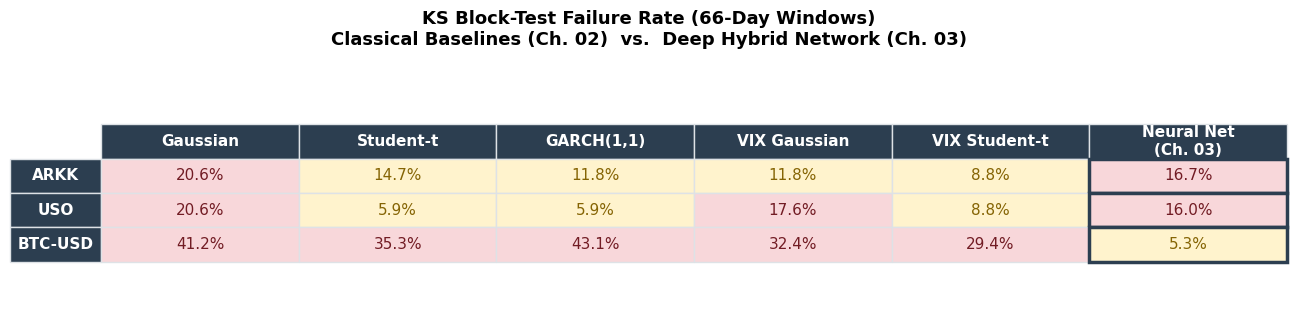

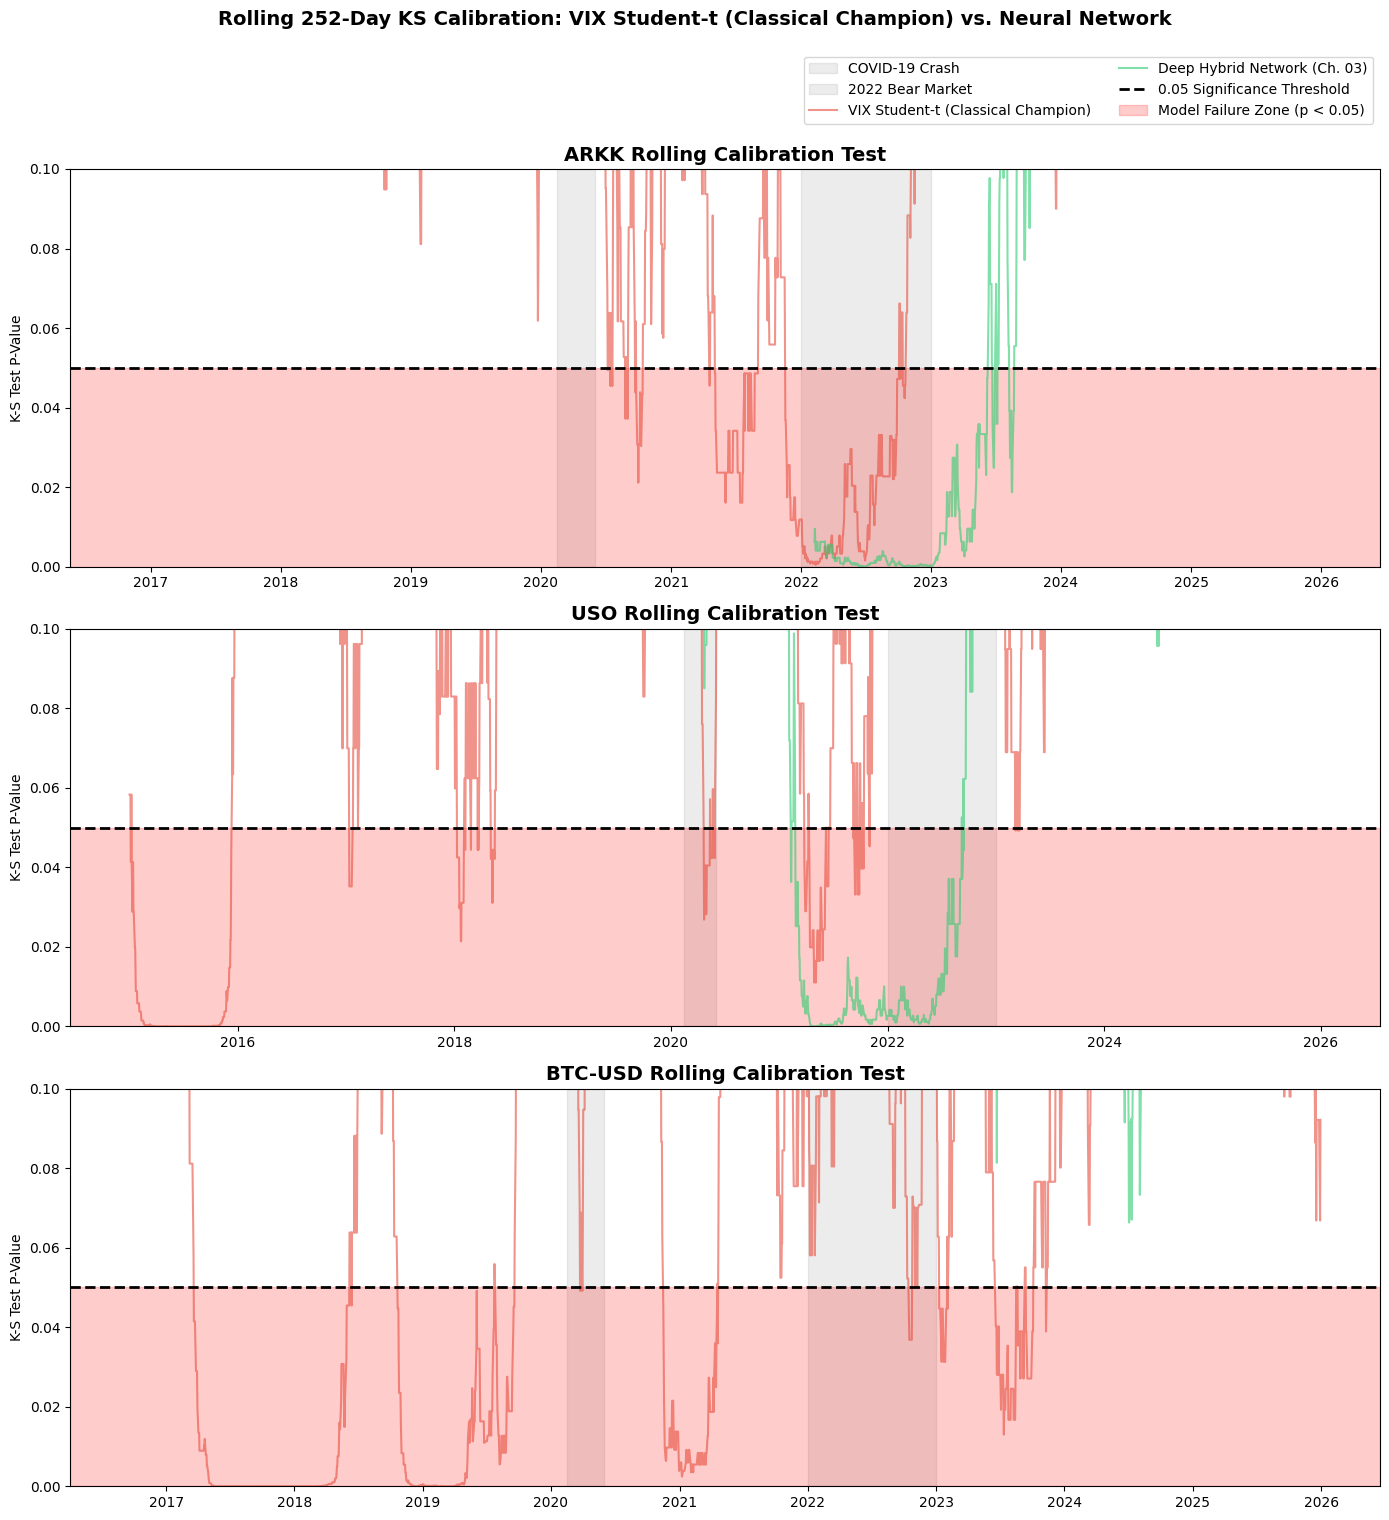

In [ ]:
import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
from src.data.data_loader import fetch_asset_data
from src.evaluation.metrics import evaluate_forecasts, rolling_ks_test, print_evaluation_summary, block_ks_test
from src.evaluation.plotting import plot_rolling_ks
from src.models.neural_networks import (
    ResidualStudentTNet, BasicStudentTNet,
    student_t_nll,
    set_seed, run_model, generate_montecarlo,
)
from src.features.features import rolling_t_fit, features_lags, create_features

import pandas as pd, json, numpy as np, torch
from src.evaluation.metrics import evaluate_forecasts
from src.evaluation.plotting import plot_model_comparison
from src.models.baselines import rolling_vix_scaled_student_t
from src.models.neural_networks import run_model, generate_montecarlo, set_seed
from src.features.features import create_features

# 1. Load saved failure rates
df_classical = pd.read_csv('../notebooks/02_results.csv', index_col=0)
with open('results.json') as f:
    neural_fail = {k.split(' - ')[1]: v for k, v in json.load(f).items()}

volatile_periods = {
    "COVID-19 Crash":   ("2020-02-15", "2020-06-01"),
    "2022 Bear Market": ("2022-01-01", "2022-12-31"),
}
tickers      = ['ARKK', 'USO', 'BTC-USD']
model_assign = {'BTC-USD': 'Basic', 'ARKK': 'Residual', 'USO': 'Basic'}

# 2. Reconstruct PIT series for each asset
pit_series_dict = {}
for ticker in tickers:
    print(f"\n── {ticker} ──")
    df       = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])
    df_vix_r = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
    df_vix_r = df_vix_r[['prices']] / np.sqrt(252)
    df_vix_r.columns = ['VIX']

    # Classical champion: VIX-Scaled Student-t
    df_ret   = df[['returns']].dropna() * 100
    df_vix_a = df_vix_r.loc[df_vix_r.index.isin(df_ret.index)]
    df_ret_a = df_ret.loc[df_ret.index.isin(df_vix_a.index)]
    pred_vix = rolling_vix_scaled_student_t(df_ret_a['returns'], df_vix_a['VIX'], window=252)
    eval_vix = evaluate_forecasts(df_ret_a['returns'].iloc[253:], pred_vix[253:])

    # Neural network: re-run walk-forward
    df_feat  = create_features(df, df_vix_r, window_size)
    X_t = torch.tensor(np.array(df_feat.drop(columns=['returns'])), dtype=torch.float32)
    y_t = torch.tensor(np.array(df_feat['returns']), dtype=torch.float32).unsqueeze(1)

    set_seed(42)
    mu_oos, sig_oos, nu_oos, oos_dates, actuals = run_model(
        X_t, y_t, df_feat.index,
        initial_train_size=initial_train_size,
        step_size=step_size,
        model_class=model_assign[ticker],
    )
    ensembles  = generate_montecarlo(mu_oos, sig_oos, nu_oos, n_samples=1000)
    eval_neural = evaluate_forecasts(pd.Series(actuals, index=oos_dates), ensembles)

    pit_series_dict[ticker] = {
        'vix_student': eval_vix['PIT'],
        'neural':      eval_neural['PIT'],
    }

# 3. Plot comparison table + rolling KS chart
plot_model_comparison(
    classical_failure_rates=df_classical,
    neural_failure_rates=neural_fail,
    pit_series_dict=pit_series_dict,
    volatile_periods=volatile_periods,
    block_size=22 * 3,
    rolling_window=252,
)


In [ ]:
columns = ['vix_student', 'neural']

for ticker, results in pit_series_dict.items():
    df_results = pd.DataFrame([])
    for col in columns:
        df_results = pd.concat([df_results, pd.DataFrame(results[col])], axis=1)
        df_results.dropna(inplace=True)
    df_results.columns = ['vix_student', 'neural']
    
    df_results_pass = pd.DataFrame([], index=df_results.index, columns=df_results.columns)
    for col in columns:
        df_results_pass.loc[df_results[col] > 0.05, col] = 0
        df_results_pass.loc[df_results[col] <= 0.05, col] = 1

    print(ticker)
    print(df_results_pass.sum() / len(df_results_pass))

# df_results_pass


ARKK
vix_student    0.057818
neural         0.045603
dtype: object
USO
vix_student    0.062685
neural         0.062685
dtype: object
BTC-USD
vix_student    0.049098
neural         0.061122
dtype: object
